# **Phase 05 - XGBoost Prediction Model**
- More accurate than RandomForest
- Works well with less than 200K rows but not with millons of data

### **How the Model Learns**
- it don't use some coulumns such as : **company, symbol, date, dup_index, future_close_10d, future_return_10d, target_buy_10**
- Imagine training data like this
| volume_z | ret_5 | range_position | liquidity_rank | target |
|----------|-------|----------------|----------------|--------|
| 1.2      | 0.03  | 0.8            | 20             | 1      |
| -0.4     | -0.02 | 0.2            | 300            | 0      |
| 0.9      | 0.05  | 0.7            | 40             | 1      |

- The model tries to learn patterns like : (It learns statistical relationships.) <br>
*IF<br>
volume_z high
AND<br>
ret_5 positive<br>
AND<br>
range_position high<br>
THEN<br>
probability of profit increases*

### Create DuckDB Connection

In [32]:
import duckdb
import os

DB_FOLDER = "database"
DB_PATH = os.path.join(DB_FOLDER, "cse_data.db")

con = duckdb.connect(database=DB_PATH)

In [33]:
stock_features_labeled_10d_df = con.execute("""
    SELECT *
    FROM stocks_features_labeled_10d_table
""").fetch_df()

features = [
    # Momentum
    "ret_5", "ret_10", "ma_ratio_5", "ma_ratio_10", "momentum_score", "trend_angle",
    # Volatility
    "std_close_10", "std_close_20", "atr_14", "volatility_score", "range_5",
    # Liquidity
    "volume_ratio", "volume_z", "liquidity_rank", "avg_vol_20",
    # Relative/position
    "price_position", "range_position", "breakout_flag"
]

X = stock_features_labeled_10d_df[features]
y = stock_features_labeled_10d_df["target_buy_10d"]

In [34]:
# !pip install xgboost

import numpy as np
from collections import Counter
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score



# ================== split data ==================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)



# ================== Fix Class Imbalance using scale_pos_weight ==================

# What scale_pos_weight does
#    It tells XGBoost : “Hey, class 1 is important — punish mistakes more!”
#    scale_pos_weight = (number of 0s) / (number of 1s)

# Count 0s and 1s in training set
counter = Counter(y_train)
print(counter)

# Calculate scale_pos_weight
scale_pos_weight = counter[0] / counter[1]
print("scale_pos_weight : ", scale_pos_weight)



# ================== Initialize XGBoost classifier ==================

xgb_model = xgb.XGBClassifier(
    n_estimators=300,      # number of trees
    learning_rate=0.05,    # step size shrinkage
    max_depth=5,           # tree depth
    subsample=0.8,         # fraction of data per tree
    colsample_bytree=0.8,  # fraction of features per tree
    scale_pos_weight= scale_pos_weight,
    use_label_encoder=False,
    eval_metric= 'logloss',
    random_state=42
)

# ================== Train ==================
xgb_model.fit(X_train, y_train)


# Predict probabilities
# here predict_proba rtuen [o.8, 0.2] such a array so [class 0, class 1] this is differ from predict() function, let conside only class 1 we need it
y_pred_proba = xgb_model.predict_proba(X_test)[:,1]
print("y_pred_proba for class 1 \n", y_pred_proba)

threshold_prob = best_threshold_prob(y_test, y_pred_proba, 0.01)
y_pred_binary = (y_pred_proba >= threshold_prob).astype(int)

# Adding new row for Top-K Backtest buy calculating probalilty of getting profit
# predict on all rows
# predict_proba() - returns two probabilities for each row > [ P(class 0), P(class 1) ] > [probability_of_0, probability_of_1]



Counter({0: 8261, 1: 1167})
scale_pos_weight :  7.078834618680377


C:\Users\Lapmart\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:32:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


y_pred_proba for class 1 
 [0.20626101 0.14413078 0.19354808 ... 0.2890261  0.1595992  0.13288489]

Best Threshold: 0.3799999999999999
Best F1: 0.3448275862068966


### tuning xgb

In [35]:
from sklearn.metrics import f1_score

def best_threshold_prob(y_test_split, y_pred_proba_list, rate):
    thresholds = np.arange(0.1, 0.9, rate)
    
    best_thresh = 0
    best_f1 = 0
    
    for t in thresholds:
        y_pred = (y_pred_proba_list >= t).astype(int)
        f1 = f1_score(y_test_split, y_pred)
    
        # print(f"Threshold: {t:.2f} | F1: {f1:.4f}")
    
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    
    print("\nBest Threshold:", best_thresh)
    print("Best F1:", best_f1)

    return best_thresh

### Adding prob col into duckdb table

In [37]:

y_pred_proba_all = xgb_model.predict_proba(X)[:, 1]

stock_features_labeled_10d_df["prob"] = y_pred_proba_all

# ================== Create new table called stocks_10d_prob_table with prob column using ==================
con.execute("""
    DROP TABLE IF EXISTS stocks_10d_prob_table
""")
con.execute("""
    CREATE OR REPLACE TABLE stocks_10d_prob_table AS
    SELECT * FROM stock_features_labeled_10d_df
""")

In [38]:
df = con.execute("SELECT * FROM stocks_10d_prob_table").fetch_df()
df.sample(5)

,company,symbol,volume,trades,prev_close,open,high,low,close,change,...,momentum_score,volatility_score,turnover_ratio,trend_angle,range_position,liquidity_rank,future_close_10d,future_return_10d,target_buy_10d,prob
8583,HAYLEYS FABRIC PLC,MGT.N0000,304028,233,36.50,36.5,36.5,34.7,35.50,-1.00,...,-0.046593,1.247554,0.000766,-0.196391,0.120000,98.0,NaN,NaN,0,0.089060
11677,TESS AGRO PLC,TESS.N0000,2481638,170,2.10,2.1,2.2,1.9,2.00,-0.10,...,0.079132,0.224017,0.000069,0.026466,0.714286,17.0,2.20,0.100000,1,0.510032
7798,THE KINGSBURY PLC,SERV.N0000,432185,158,18.10,18.1,18.6,18.1,18.20,0.10,...,-0.018592,0.314550,0.000366,-0.118872,0.037037,69.0,14.00,-0.230769,0,0.300869
10708,LAKE HOUSE PRINTERS & PUBLISHERS PLC,LPRT.N0000,2429,64,527.75,545.0,610.0,530.0,560.00,32.25,...,0.144077,41.407612,0.026348,1.769737,1.000000,281.0,745.75,0.331696,1,0.836285
7318,CEYLON HOSPITALS PLC,CHL.N0000,28318,78,354.75,340.0,355.0,340.0,341.75,-13.00,...,0.054068,25.523556,0.002754,5.739474,0.686975,186.0,341.00,-0.002195,0,0.262960


### Evaluation

In [39]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate ROC AUC
# Receiver Operating Characteristic – Area Under Curve
# How well your model separates Class 0 and Class 1

roc_auc = roc_auc_score(y_test, y_pred_proba)

preds = y_pred_binary

print("ROC AUC:", roc_auc,"\n")
print(classification_report(y_test, preds))

ROC AUC: 0.6952236785054122 

              precision    recall  f1-score   support

           0       0.91      0.79      0.85      2035
           1       0.27      0.48      0.34       323

    accuracy                           0.75      2358
   macro avg       0.59      0.64      0.60      2358
weighted avg       0.82      0.75      0.78      2358



### **Note**
ROC AUC: 0.7108237424026898 

              precision    recall  f1-score   support

           0       0.88      0.98      0.93      2035
           1       0.58      0.13      0.21       323

    accuracy                           0.87      2358
   macro avg       0.73      0.56      0.57      2358
weighted avg       0.84      0.87      0.83      2358

**Since we work with do investment not to avoid so focus on one class 1**


- **Accuracy** = how many predictions are correct
  - **Correct predictions / Total predictions**
- **Precision** = How correct are your "YES" predictions ( trust level of predictions ) (quality)
  - When model says "1", how often is it correct? when model say for row lable '1' is 0.58 then >> Model predicted 100 stocks as "good" but 58 actually good
  - **Correct 1 predictions / All predicted 1**
- **Recall** = How many real "good stocks" you found (Coverage)
  - Eg 0.13 for '1' >>> There are 100 real good stocks in the table but Model found only 13
- **F1 Score** = Balance of precision + recall >>> “Is my model BOTH accurate AND finding enough positives?”
  - is model found most buying opportunities that actualy can buy for profit
  - For 'class 1' > 0.21 BAD
- **Support** = Just count - Number of actual samples
- **ROC AUC** = Model ranking ability
  - How well model separates 0 vs 1
  - 0.5 → random guessing & 1.0 → perfect
- **Macro Avg** = Treats both classes equally
- **Weighted Avg** = Weighted by number of samples

**IMPORTANT - We are ONLY talking about class = 1 (BUY)**
- High precision = you can trust predictions
- Low precision = many wrong trades

- High recall = you catch opportunities
- Low recall = you miss profits

- cannot maximize both easily

Imagine fishing
---------------

- Precision = fish you caught are edible

- Recall = how many fish you caught from the lake

Case 1:
- Catch 2 fish, both good → high precision, low recall
👉 You starve 😅

Case 2:
- Catch 20 fish, 10 good → lower precision, high recall
👉 You can still eat 👍

### ROC Graph

Blue curve → model
Red dashed line → random guessing (AUC = 0.5)
The closer the blue curve is to top-left, the better the model


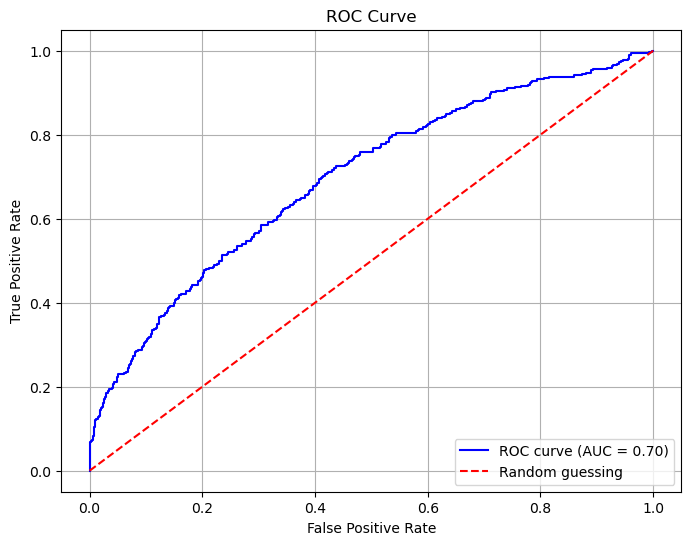

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# y_test → true labels
# y_pred_proba → predicted probability for class 1 (BUY)
# fpr → False Positive Rate = FP / (FP + TN)
# tpr → True Positive Rate = TP / (TP + FN)
# thresholds → probability thresholds used    
fpr, tpr, thrsholds = roc_curve(y_test, y_pred_proba)

# Compute area under curve
roc_auc = auc(fpr, tpr)

print("Blue curve → model")
print("Red dashed line → random guessing (AUC = 0.5)")
print("The closer the blue curve is to top-left, the better the model")

# Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### XGB Model Evaluation

In [41]:
stock_features_labeled_10d_df.head()

,company,symbol,volume,trades,prev_close,open,high,low,close,change,...,momentum_score,volatility_score,turnover_ratio,trend_angle,range_position,liquidity_rank,future_close_10d,future_return_10d,target_buy_10d,prob
0,ABANS ELECTRICALS PLC,ABAN.N0000,813,47,1201.50,1215.00,1255.00,1202.0,1247.25,45.75,...,-0.045714,92.578046,0.057811,-18.365038,0.116486,244.0,1300.75,0.042894,0,0.082065
1,ABANS ELECTRICALS PLC,ABAN.N0000,7959,276,1247.25,1254.00,1550.00,1245.0,1393.00,145.75,...,0.056660,99.845589,0.034678,-18.771805,0.487588,251.0,1297.00,-0.068916,0,0.069746
2,ABANS ELECTRICALS PLC,ABAN.N0000,10714,72,1393.00,1390.00,1420.00,1390.0,1400.00,7.00,...,0.017430,107.925534,0.006720,-17.821992,0.505411,251.0,1280.25,-0.085536,0,0.054725
3,ABANS ELECTRICALS PLC,ABAN.N0000,578,51,1396.50,1390.00,1410.00,1370.0,1373.25,-23.25,...,0.010639,99.233277,0.088235,-17.015789,0.437301,251.0,1279.50,-0.068269,0,0.030592
4,ABANS ELECTRICALS PLC,ABAN.N0000,425,53,1374.00,1398.75,1398.75,1350.0,1351.25,-22.75,...,0.010362,78.968160,0.124706,-16.675752,0.381286,255.0,1237.50,-0.084181,0,0.061209


In [42]:
tables = con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
""").fetch_df()

print(tables)

                           table_name
0                    raw_stocks_table
1               stocks_10d_prob_table
2                  stocks_clean_table
3         stocks_features_clean_table
4   stocks_features_labeled_10d_table
5               stocks_features_table
6                 stocks_sorted_table
7                        stocks_table
8             temp_future_price_table
9                temp_liquidity_table
10                 temp_returns_table
11                   temp_trend_table
12                      temp_tr_table
13                     temp_vol_table


### Close DuckDB Connection

In [43]:
if 'con' in globals():  # Check if connection exists
    try:
        con.close()        # Close it
        print("DuckDB connection closed.")
    except Exception as e:
        print("Error closing DuckDB:", e)
    finally:
        del con             # Delete the variable from memory

DuckDB connection closed.
